# Credit Card Fraud Detection

## Objective
Identify **fraudulent credit card transactions** using machine learning.

## Dataset Overview
The dataset contains anonymized credit card transactions labeled as fraud or not.

- `Time`, `Amount`, and anonymized features `V1` to `V28`
- `Class`: 1 for fraud, 0 for non-fraud

## Workflow
1. Load and explore the dataset
2. Handle class imbalance
3. Feature scaling and model training
4. Evaluate performance

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [12]:
# Load the dataset
df = pd.read_csv("creditcard.csv")
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Exploratory Data Analysis

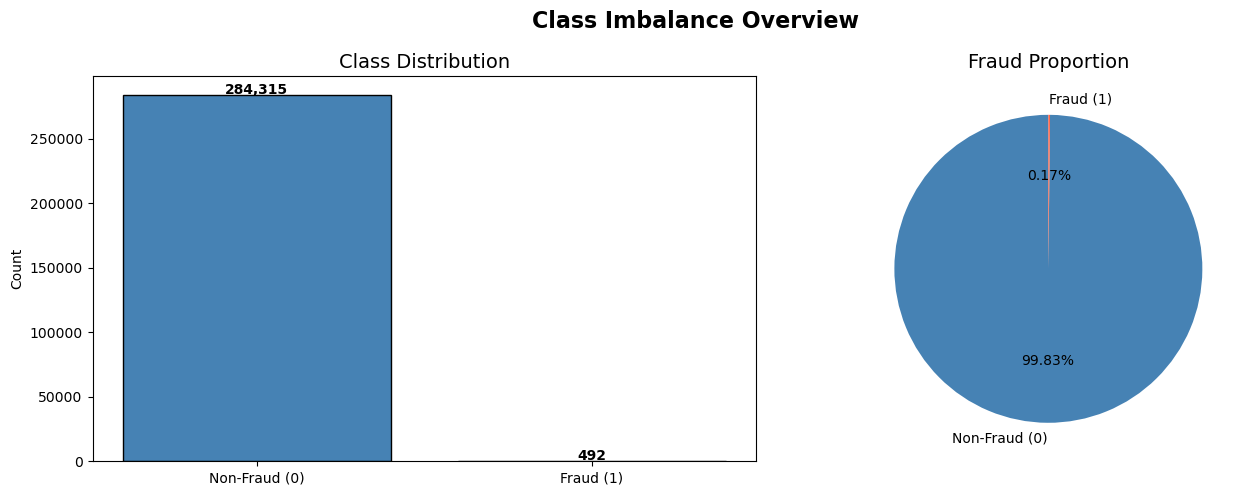

Non-Fraud transactions : 284,315 (99.83%)
Fraud transactions     : 492 (0.17%)


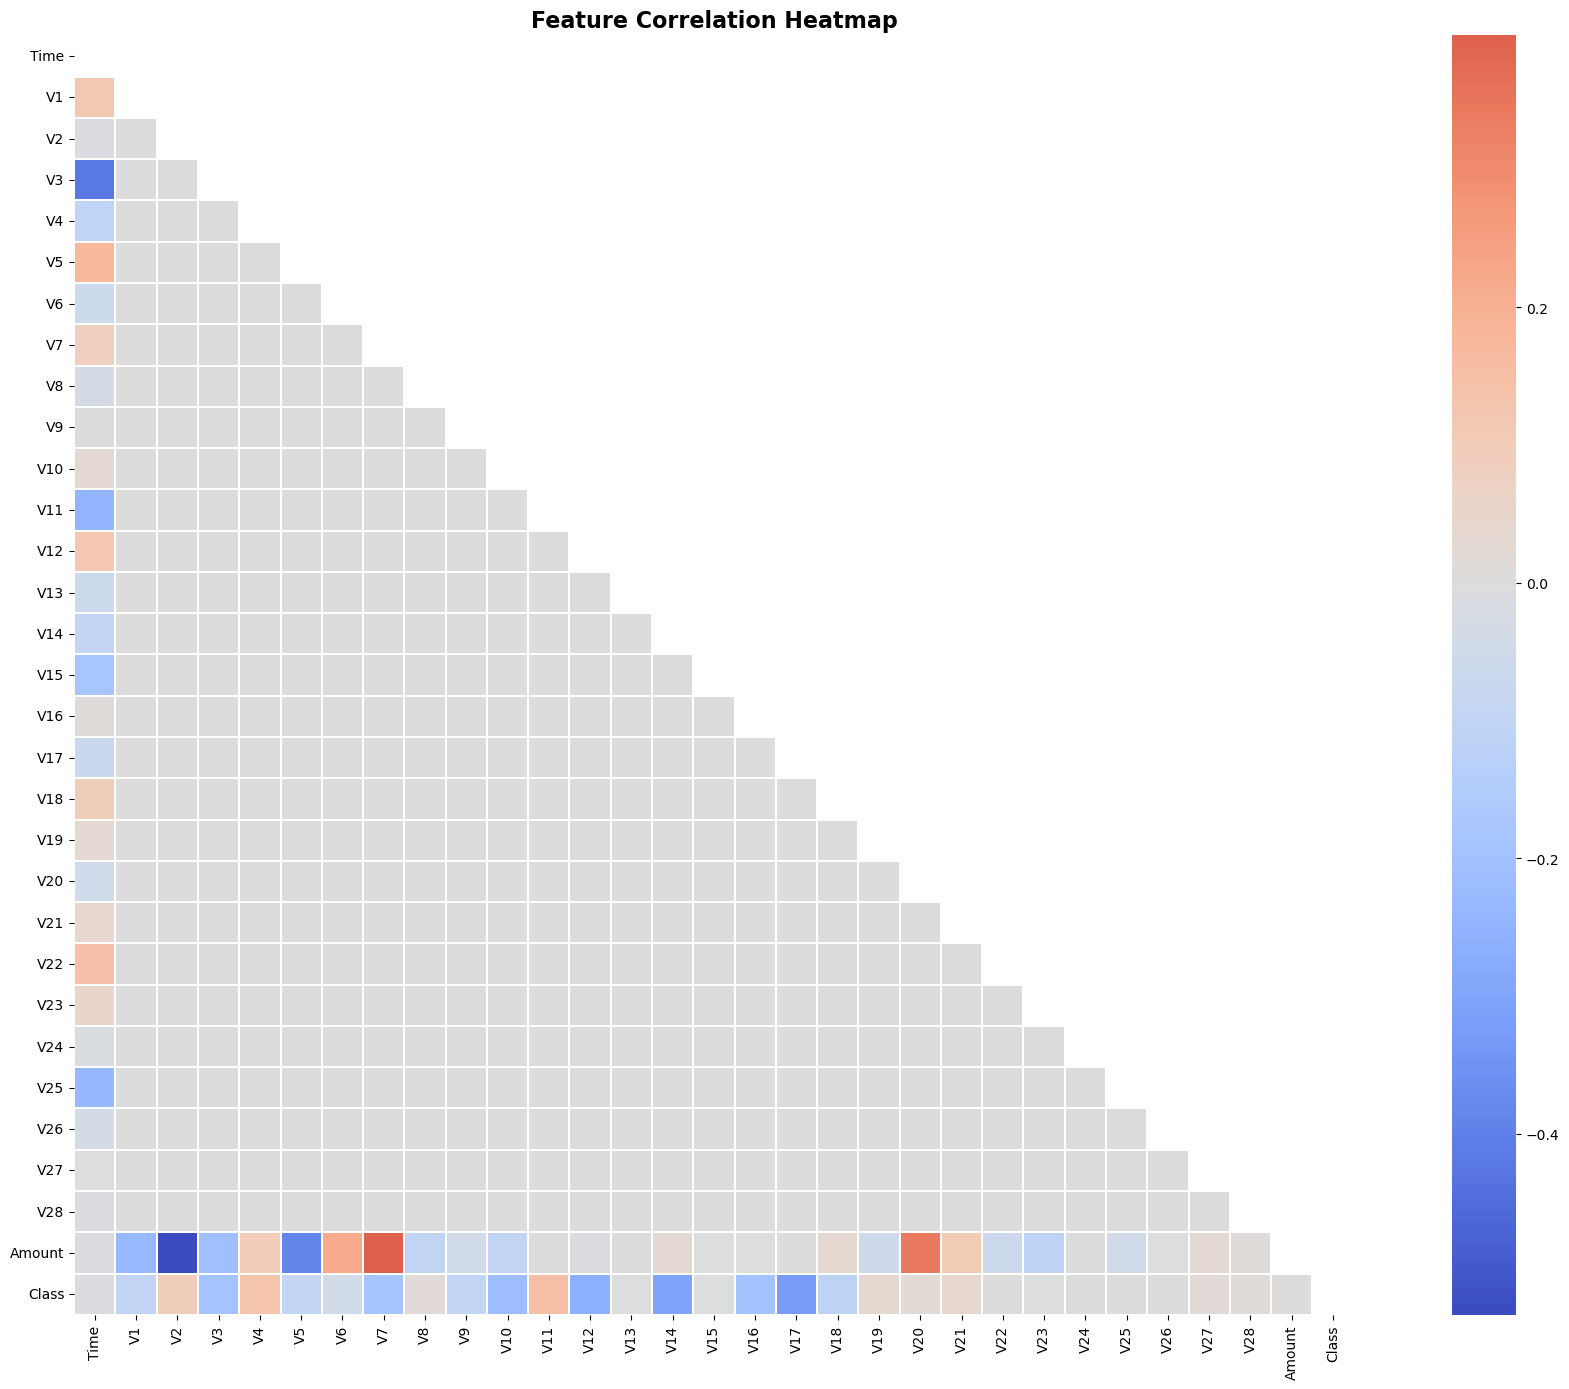

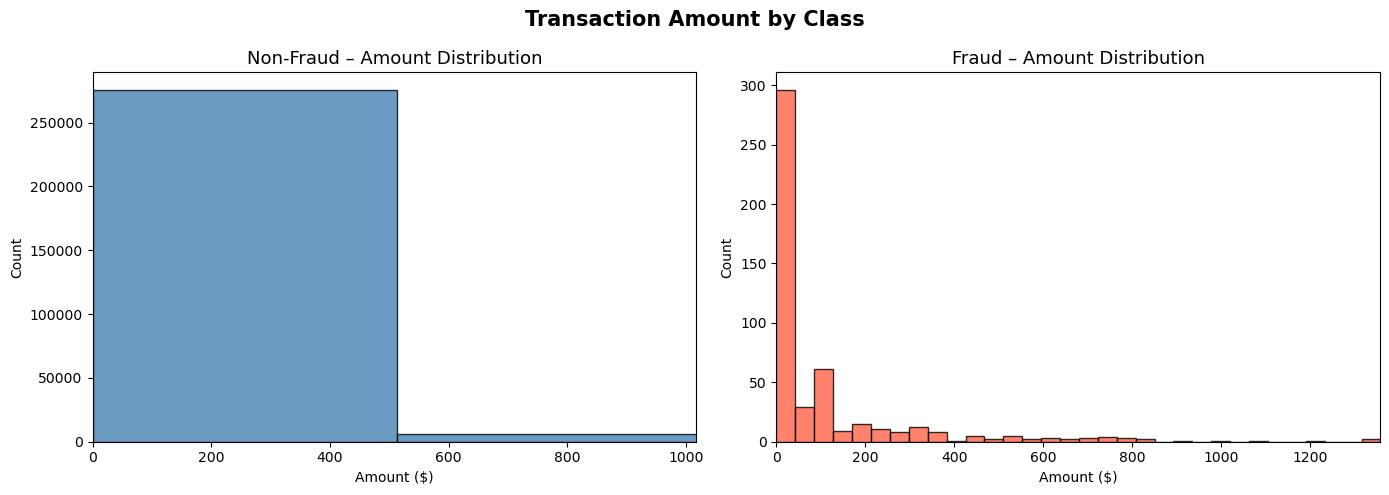

In [6]:
# Count of fraud vs non-fraud
# ── 1. Class Distribution (Fraud vs Non-Fraud) ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts = df['Class'].value_counts()
labels = ['Non-Fraud (0)', 'Fraud (1)']

# Bar plot
axes[0].bar(labels, class_counts.values, color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Class Distribution', fontsize=14)
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values, labels=labels, autopct='%1.2f%%',
            colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Fraud Proportion', fontsize=14)

plt.suptitle('Class Imbalance Overview', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Non-Fraud transactions : {class_counts[0]:,} ({class_counts[0]/len(df)*100:.2f}%)")
print(f"Fraud transactions     : {class_counts[1]:,} ({class_counts[1]/len(df)*100:.2f}%)")

# Correlation heatmap
plt.figure(figsize=(20, 14))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))   # show lower triangle only
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            linewidths=0.3, annot=False, square=True)
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 3. Transaction Amount Distribution by Class ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cls, color, label, ax in zip(
        [0, 1], ['steelblue', 'tomato'],
        ['Non-Fraud', 'Fraud'], axes):
    subset = df[df['Class'] == cls]['Amount']
    ax.hist(subset, bins=50, color=color, edgecolor='black', alpha=0.8)
    ax.set_title(f'{label} – Amount Distribution', fontsize=13)
    ax.set_xlabel('Amount ($)')
    ax.set_ylabel('Count')
    ax.set_xlim(0, subset.quantile(0.99))   # clip extreme outliers for readability

plt.suptitle('Transaction Amount by Class', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Data Preprocessing

In [13]:
# Feature scaling for 'Amount' and 'Time'
scaler = StandardScaler()

df['scaled_Amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['scaled_Time']   = scaler.fit_transform(df['Time'].values.reshape(-1, 1))

# Drop original unscaled columns
df.drop(columns=['Amount', 'Time'], inplace=True)

# Move scaled columns to the front for clarity
cols = ['scaled_Amount', 'scaled_Time'] + \
       [c for c in df.columns if c not in ('scaled_Amount', 'scaled_Time', 'Class')] + \
       ['Class']
df = df[cols]

print('Preprocessing complete. New shape:', df.shape)
df.head()

# ── Handle Class Imbalance via Under-Sampling ────────────────────────────────
# Keep all fraud rows + a random equal-sized sample of non-fraud rows
fraud_df     = df[df['Class'] == 1]
non_fraud_df = df[df['Class'] == 0].sample(n=len(fraud_df), random_state=42)

balanced_df = pd.concat([fraud_df, non_fraud_df]).sample(frac=1, random_state=42).reset_index(drop=True)

print('Balanced dataset shape:', balanced_df.shape)
print(balanced_df['Class'].value_counts())


Preprocessing complete. New shape: (284807, 31)
Balanced dataset shape: (984, 31)
Class
0    492
1    492
Name: count, dtype: int64


## Model Training

In [14]:
# Define features and target

# Train-test split with stratification

# Logistic Regression


# Predictions

# ── Define Features and Target ───────────────────────────────────────────────
X = balanced_df.drop(columns='Class')
y = balanced_df['Class']

# ── Train-Test Split with Stratification ─────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples : {len(X_train):,}')
print(f'Test samples     : {len(X_test):,}')

# ── Train Logistic Regression ─────────────────────────────────────────────────
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

# ── Predictions ───────────────────────────────────────────────────────────────
y_pred      = log_reg.predict(X_test)
y_pred_prob = log_reg.predict_proba(X_test)[:, 1]

print('\nModel training complete!')



Training samples : 787
Test samples     : 197

Model training complete!


## Evaluation

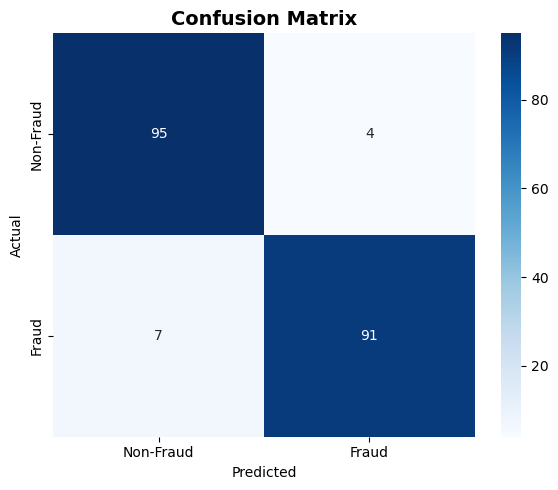

Classification Report
              precision    recall  f1-score   support

   Non-Fraud       0.93      0.96      0.95        99
       Fraud       0.96      0.93      0.94        98

    accuracy                           0.94       197
   macro avg       0.94      0.94      0.94       197
weighted avg       0.94      0.94      0.94       197

Overall Accuracy : 0.9442


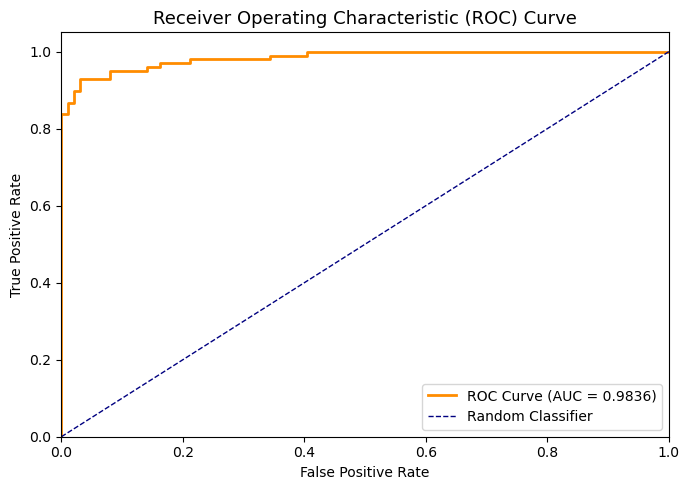

ROC-AUC Score: 0.9836


In [16]:
# Confusion matrix and classification report
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Fraud', 'Fraud'],
            yticklabels=['Non-Fraud', 'Fraud'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# ── Classification Report ─────────────────────────────────────────────────────
print('=' * 50)
print('Classification Report')
print('=' * 50)
print(classification_report(y_test, y_pred, target_names=['Non-Fraud', 'Fraud']))
print(f'Overall Accuracy : {accuracy_score(y_test, y_pred):.4f}')

# ── ROC-AUC Curve ─────────────────────────────────────────────────────────────
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
auc_score   = roc_auc_score(y_test, y_pred_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=13)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f'ROC-AUC Score: {auc_score:.4f}')




## Conclusion
- Used logistic regression for binary classification.
- Addressed feature scaling and class imbalance.
- Future work: try ensemble methods (e.g. Random Forest, XGBoost) or SMOTE for better fraud detection.